# Industrial Surface Defect Classification using Transfer Learning 

## Objective

The aim of this assignment is to automatically classify surface defects in steel materials using real-world industrial image data and a transfer learning approach.

Surface defects such as cracks, scratches, inclusions, and pits commonly occur during manufacturing processes and can significantly affect product quality. Manual inspection of these defects is time-consuming, inconsistent, and difficult to scale.

In this assignment, we use a dataset containing steel surface images belonging to six different defect categories:
- Crazing  
- Inclusion  
- Patches  
- Pitted Surface  
- Rolled-in Scale  
- Scratches  

All defect types originate from the same manufacturing domain, and learning from all categories together allows the model to capture shared texture and structural patterns present across industrial surfaces.

The problem statement for this assignment is:

> **Given a steel surface image, predict the type of surface defect present in the image using a pretrained convolutional neural network.**

To solve this problem efficiently, we apply **transfer learning** by reusing a pretrained `MobileNetV2` model as a feature extractor and training only a lightweight classification head. This demonstrates how deep learning models can be adapted to real industrial use cases using limited data and computational resources.

## Business Value

In manufacturing industries such as steel, automotive, and heavy engineering, surface defects can directly impact product quality, safety, customer satisfaction, production cost, and rework rates.

Traditional inspection methods rely heavily on human inspectors, which introduces inconsistency in defect detection. Manual inspection also comes with high operational costs and scalability limitations.

By applying transfer learning, organisations can:
- Reuse pretrained visual intelligence instead of training models from scratch  
- Reduce development and training time  
- Achieve reliable defect detection even with smaller datasets  
- Deploy lightweight models suitable for real-time or edge-based inspection systems

## Dataset Description

This assignment uses the **NEU Surface Defect Dataset**, a real-world industrial dataset commonly used in manufacturing research and automated inspection systems.

### Dataset Characteristics:
- Images represent steel surface textures captured under industrial conditions  
- Each image belongs to one of six defect categories:
  - Crazing  
  - Inclusion  
  - Patches  
  - Pitted Surface  
  - Rolled-in Scale  
  - Scratches  
- Images are originally grayscale
- The dataset is reasonably balanced across classes  


#### Why this dataset?

- It represents a real industrial computer vision problem
- Defect patterns are texture-based, making it ideal for demonstrating transfer learning  
- The dataset size is moderate, encouraging the use of **partial transfer learning** rather than full model retraining  

## Flow Diagram

![Screenshot 2026-01-25 at 12.45.36 PM.png](<attachment:Screenshot 2026-01-25 at 12.45.36 PM.png>)
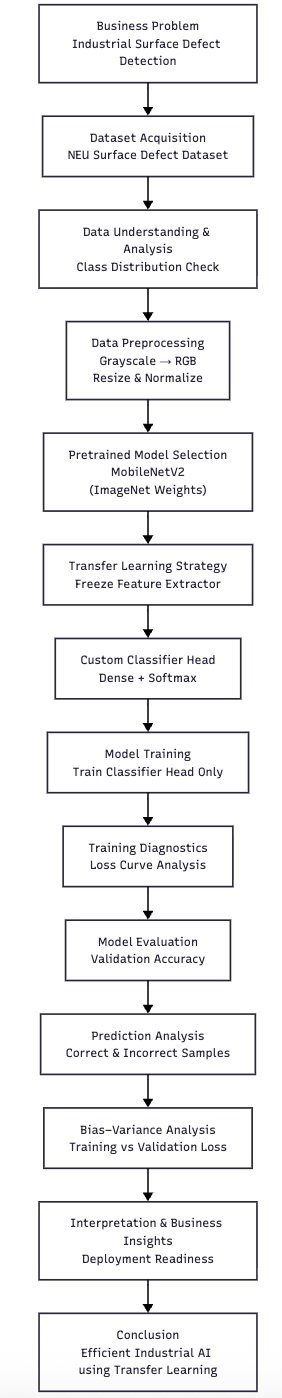

**Note:** You are free to choose any pre-trained model from the available ones. However, the architecture we suggest for this assignment is `MobileNetV2` with "ImageNet" weights.

The choice of libraries, frameworks, and backbones for this assignment are up to you. Before starting this assignment, please ensure that your environment meets the following requirements.


**Software Requirements**

- *Python version*: > Python3.11  
- *Execution environment*: Jupyter Notebook / JupyterLab / VS Code Notebook  
- *Operating system*: macOS, Linux, or Windows  


**Hardware Requirements**
- A GPU-powered training would be optimal, and would require installation of proper libraries and CUDA
- However, CPU-only execution might also be sufficient, and would work without CUDA

### Import Necessary libraries

In [2]:
# Import Required Libraries
import os
import torch
import torchvision
import matplotlib


## 1. Data Loading and Preparation 

<font color=red>[10 marks]</font>

In any machine learning workflow, understanding and preparing the data correctly is a critical first step. Before building a deep learning model, it is important
to examine how the dataset is structured, how labels are assigned, and how images are preprocessed for training.

This section includes the following steps:
- Understanding the dataset organisation
- Verifying class labels and distributions
- Applying appropriate image transformations for transfer learning
- Development of train loader and validation loader

### 1.1 Dataset Understanding and Structure 

<font color=red>[4 marks]</font>

The NEU Surface Defect Dataset consists of real-world grayscale images collected from steel manufacturing processes. Each image belongs to one of six surface defect categories.

The dataset is already split into **training** and **validation** sets, and images are organised into class-specific folders. This structure allows us to use PyTorch’s `ImageFolder` utility, which automatically assigns labels based on directory names.

The same directory-based structure is also compatible with TensorFlow, allowing the dataset to be loaded directly using `tf.keras.utils.image_dataset_from_directory`, which infers class labels from folder names in a similar manner.



Before proceeding, we load the dataset and verify:
- Number of images in training and validation sets
- Mapping between class names and numeric labels

#### **1.1.1** Load Images and Labels  <font color=red>[3 marks]</font>

Load the training and validation datasets and check the number of images and the number of categories present

In [5]:
# Load training and validation images + labels
from torchvision.datasets import ImageFolder

train_path = "./train/images"
val_path   = "./validation/images"

train_dataset = ImageFolder(train_path)
val_dataset = ImageFolder(val_path)

# Dataset statistics
print("Classes:", train_dataset.classes)
print("Number of classes:", len(train_dataset.classes))
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

print(train_dataset[0])



Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Number of classes: 6
Training images: 1440
Validation images: 360
(<PIL.Image.Image image mode=RGB size=200x200 at 0x7E1AD4D62450>, 0)


Here, the image loader automatically assigns numeric labels based on folder names. For example, all images inside the "crazing" folder receive the same label.

This approach reduces manual labeling effort and ensures consistency between directory structure and class definitions.

#### **1.1.2** Check and Visualise Class Distribution <font color=red>[1 mark]</font>

In [6]:
# Dataset Class Distribution
from collections import Counter

train_counts = Counter(train_dataset.targets)
print("Training class distribution:", train_counts)

Training class distribution: Counter({0: 240, 1: 240, 2: 240, 3: 240, 4: 240, 5: 240})


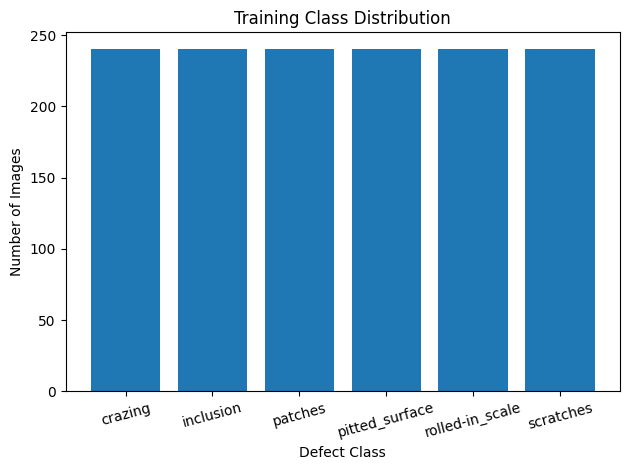

In [7]:
# Visualise class distribution
import matplotlib.pyplot as plt

classes = train_dataset.classes
counts = [train_counts[i] for i in range(len(classes))]

plt.bar(classes, counts)
plt.title("Training Class Distribution")
plt.xlabel("Defect Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### 1.2 Data Preprocessing and Transformations 

<font color=red>[6 marks]</font>

Deep learning models pretrained on ImageNet expect images to be in a specific format. Although the NEU dataset images are grayscale, ImageNet-pretrained models require 3-channel RGB images with standardised dimensions and normalisation.

#### **1.2.1** Apply Image Transformations <font color=red>[4 marks]</font>

To ensure compatibility, we apply the following transformations:
- Convert grayscale images to RGB
- Resize images to a fixed resolution
- Normalize using ImageNet mean and standard deviation

These transformations are provided in [`transforms`](https://docs.pytorch.org/vision/0.24/transforms.html) from `torchvision`, while in TensorFlow the same preprocessing steps are applied using [`tf.image`](https://www.tensorflow.org/api_docs/python/tf/image) operations and `tf.keras.layers` within the input pipeline.

In PyTorch, normalization can be performed using `Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)`.

In TensorFlow, the same effect is achieved by explicitly standardising the images with the ImageNet statistics, i.e. subtracting `IMAGENET_MEAN` and dividing by `IMAGENET_STD` using `tf.image` operations or a custom `tf.keras.layers.Layer` within the preprocessing pipeline.

In [9]:
# Image Transformations

from torchvision import transforms
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_dataset = ImageFolder(train_path, transform=transform)
val_dataset   = ImageFolder(val_path, transform=transform)

# Verify one sample shape
image, label = train_dataset[0]
print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([3, 224, 224])
Label: 0


At this stage, the dataset is fully prepared for training a transfer learning model. Images are correctly formatted, normalized, and labeled, ensuring a smooth transition into model design and training.

#### **1.2.2** Create DataLoaders for both the training and validation datasets <font color=red>[2 marks]</font>


Deep learning models are trained on data in **batches** rather than loading the entire dataset into memory at once.

PyTorch provides the [`DataLoader`](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) utility to batch the data, shuffle training samples and load data efficiently during training. For Tensorflow, you can use similar functionality provided by [`tf.data.Dataset` API](https://www.tensorflow.org/api_docs/python/tf/data/Dataset), which supports efficient batching, shuffling, prefetching, and parallel data loading within the input pipeline.

In [10]:
# DataLoader Creation

from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 45
Validation batches: 12


Also decide on where to use shuffling - training or validation

## 2. Transferring Knowledge and Model Training

<font color=red>[25 marks]</font>

Training deep learning models from scratch requires large amounts of labeled data and computational resources. In many real-world scenarios, this is not feasible. Transfer learning addresses this challenge by reusing knowledge learned from a large source dataset (such as ImageNet) and adapting it to a new, related task.

### 2.1 Pretrained Model Selection

<font color=red>[15 marks]</font>

For this assignment, we will prefer **MobileNetV2**, a lightweight convolutional neural network pretrained on the ImageNet dataset. Though any pre-trained network will suit the task.

MobileNetV2 is computationally efficient and lightweight. It performs well on texture-based image classification tasks.

In this section:
- Select a suitable pretrained convolutional neural network
- Apply a partial transfer learning strategy
- Design a task-specific classifier for surface defect detection

#### **2.1.1** Load the Pre-Trained Model <font color=red>[5 marks]</font>

Load the pre-trained model of your choice. If you wish to use a different architecture from MobileNet, also explain the reason for your choice.

In [11]:
# Load Pretrained Network
import torchvision.models as models
model = models.mobilenet_v2(weights='IMAGENET1K_V1')

print(model)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /home/abinas/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100.0%


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

The MobileNetV2 architecture consists of two main components:
- A **feature extractor** that learns visual representations
- A **classifier head** originally designed for ImageNet’s 1000 classes

#### **2.1.2** Freezing Strategy and Classifier Design <font color=red>[8 marks]</font>

Build the transfer learning model by loading and freezing the feature extractor layers. 


Instead of retraining the entire network, we apply partial transfer learning. In this approach the pretrained feature extractor is frozen and only the classifier head is retrained for the new task. This strategy reduces the risk of overfitting and speeds up training.

In [13]:
# Build Transfer Learning Model

for param in model.features.parameters():
    param.requires_grad = False


model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2),
    torch.nn.Linear(in_features=1280, out_features=6)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Using device:", device)
print("Classifier:", model.classifier)

Using device: cpu
Classifier: Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=6, bias=True)
)


#### **2.1.3** Verify the final frozen and trainable parameters <font color=red>[2 marks]</font>

In [14]:
# Verify Freezing Strategy
total_params     = 0
trainable_params = 0

for param in model.parameters():
    total_params += param.numel()
    if param.requires_grad:
        trainable_params += param.numel()

frozen_params = total_params - trainable_params

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {frozen_params:,}")


Total parameters:     2,231,558
Trainable parameters: 7,686
Frozen parameters:    2,223,872


### 2.2 Model Training 

<font color=red>[10 marks]</font>

After designing the transfer learning model, the next step is to train it on the prepared dataset.

We only train the classifier head, while the pretrained feature extractor remains frozen. This allows the model to adapt quickly to the surface defect classification task.

In this section, we:
- Configure the training setup
- Train the model for a small number of epochs
- Track training loss to verify learning progress

#### **2.2.1** Training Configuration <font color=red>[3 marks]</font>

Before starting the training loop, we define:
- The computation device: CPU or GPU
- The loss function: Use a suitable loss function (one of the cross-entropy losses would work fine here)
- The optimizer: preferably [Adam](https://arxiv.org/abs/1412.6980) from [Tensorflow](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) or [Pytorch](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html)

These components control how the model learns from data and how its parameters are updated during training.

In [15]:
# Training Configuration
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)


Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


#### **2.2.2** Model Training Loop <font color=red>[5 marks]</font>

Perform the training and track the training loss across epochs to verify whether the model is learning effectively.

The training loop iterates over the dataset multiple times (epochs). For each batch of images, the model:
- Performs a forward pass
- Computes the loss
- Updates the trainable parameters using backpropagation

In [16]:
# Model Training
NUM_EPOCHS = 10
train_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = model(images)
        
        loss = criterion(outputs, labels)
        
        loss.backward()
        
        optimizer.step()

        running_loss += loss.item()

    
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Loss: {epoch_loss:.4f}")


Epoch 1/10 - Loss: 0.5668
Epoch 2/10 - Loss: 0.1678
Epoch 3/10 - Loss: 0.0926
Epoch 4/10 - Loss: 0.0902
Epoch 5/10 - Loss: 0.0678
Epoch 6/10 - Loss: 0.0572
Epoch 7/10 - Loss: 0.0458
Epoch 8/10 - Loss: 0.0392
Epoch 9/10 - Loss: 0.0370
Epoch 10/10 - Loss: 0.0403


#### **2.2.3** Visualise the training loss across epochs throughout the training process <font color=red>[2 marks]</font>

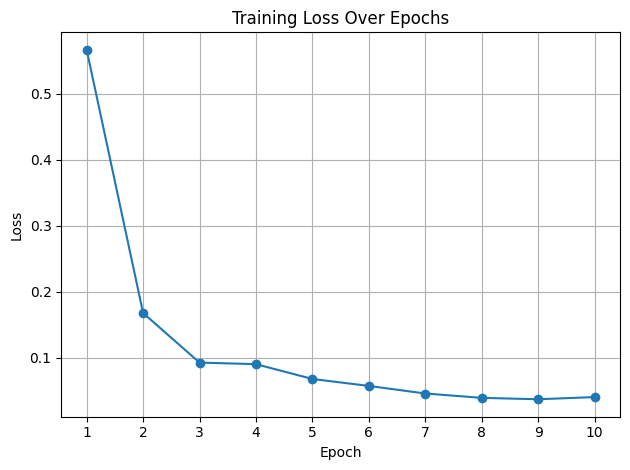

In [17]:
# Training Loss Visualisation
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, marker='o')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, NUM_EPOCHS + 1))
plt.grid(True)
plt.tight_layout()
plt.show()



## 3. Evaluation and Final Predictions

<font color=red>[10 marks]</font>

After training the model, it is essential to evaluate how well it performs on unseen data. Evaluation helps us understand whether the model has learned generalisable patterns or has simply memorised the training data.

In this section, we:
- Measure model performance using validation accuracy
- Analyse predictions at the individual data-point level
- Examine model behavior using diagnostic plots

### 3.1 Evaluation Metrics and Bias-Variance Tradeoff

<font color=red>[6 marks]</font>

#### **3.1.1** Calculate Appropriate Evaluation Metrics to Assess Model Performance <font color=red>[3 marks]</font>

For this multi-class classification problem, we use **accuracy** as the primary evaluation metric.

Accuracy measures the proportion of validation samples that are correctly classified by the model. Since the dataset is reasonably balanced across classes, accuracy provides a reliable indication of overall performance.

In [18]:
# Model Evaluation
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 98.06%


#### **3.1.2** Dataset Diagnostics <font color=red>[3 marks]</font>

Beyond accuracy, diagnostic analysis helps assess whether the model is underfitting, overfitting, or generalising well

Analyse this using training and validation loss trends, along with dataset class distribution.

Final Training Loss:   0.0403
Final Validation Loss: 0.0489


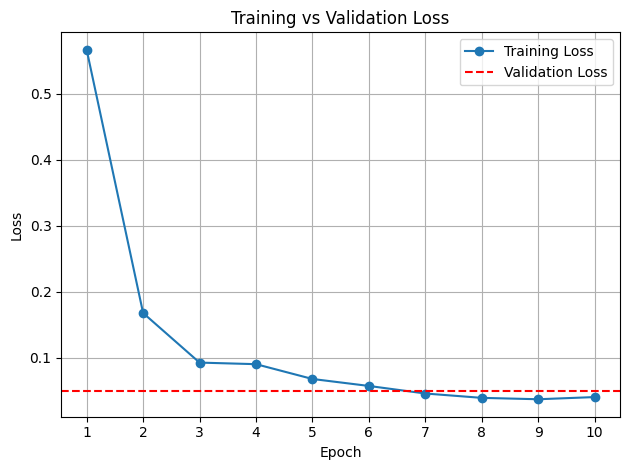

In [22]:
# Training and Validation Loss Analysis

model.eval()
val_losses = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        val_losses.append(loss.item())

avg_val_loss = sum(val_losses) / len(val_losses)
final_train_loss = train_losses[-1]

print(f"Final Training Loss:   {final_train_loss:.4f}")
print(f"Final Validation Loss: {avg_val_loss:.4f}")

plt.plot(range(1, NUM_EPOCHS + 1), train_losses, marker='o', label='Training Loss')
plt.axhline(y=avg_val_loss, color='red', linestyle='--', label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, NUM_EPOCHS + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 3.2 Prediction Analysis

<font color=red>[4 marks]</font>

Overall accuracy provides a summary metric, but it does not reveal how individual predictions contribute to that score.

To better understand model behavior, we examine predictions at the individual image level, highlighting both correct and incorrect classifications.

#### **3.2.1** Visualise the prediction on a few sample images from validation set <font color=red>[4 marks]</font>

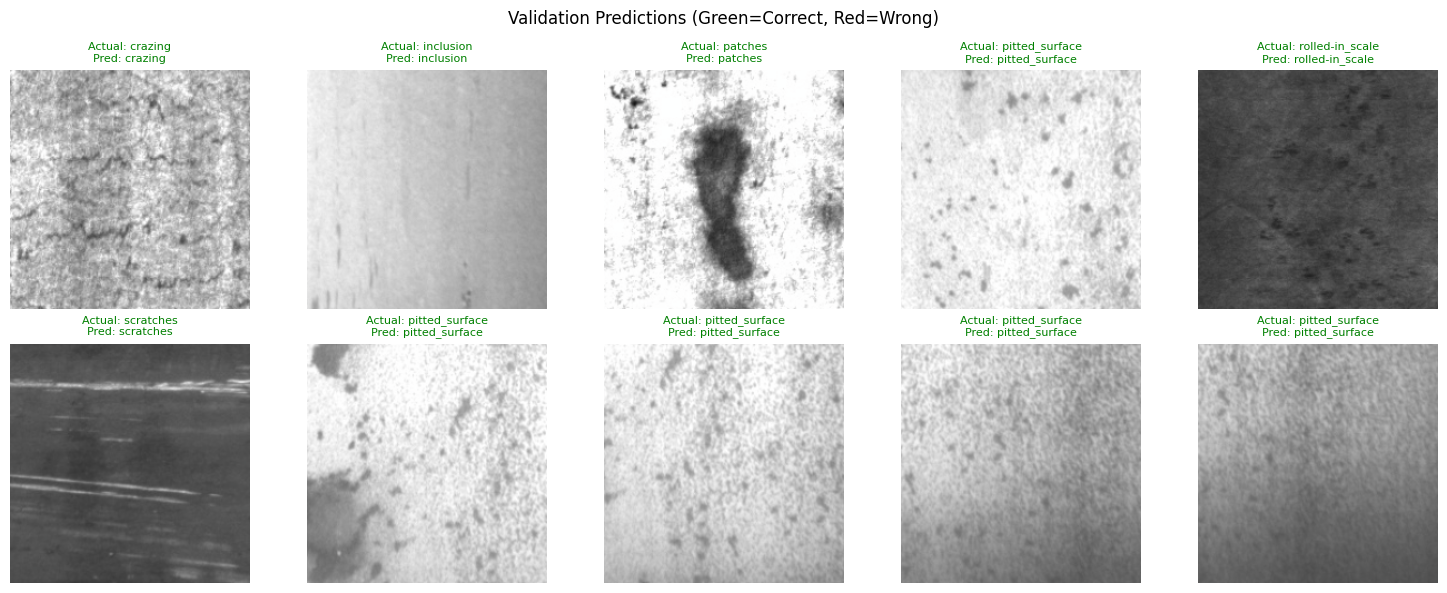

In [25]:
# Visualisation of Validation Predictions
import matplotlib.pyplot as plt
import numpy as np

# Pick one image per class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

model.eval()
class_shown = {}  # track which classes we've shown
samples = []

# Collect one sample per class
for img, label in val_dataset:
    label_name = val_dataset.classes[label]
    if label_name not in class_shown:
        class_shown[label_name] = True
        samples.append((img, label))
    if len(samples) == 6:
        break

extras = [val_dataset[i] for i in range(200, 204)]
samples = samples + extras

with torch.no_grad():
    for i, (img, label) in enumerate(samples):
        img_tensor = img.unsqueeze(0).to(device)
        output = model(img_tensor)
        _, pred = torch.max(output, 1)

        img_np = img.numpy().transpose(1, 2, 0)
        img_np = img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        img_np = np.clip(img_np, 0, 1)

        actual = val_dataset.classes[label]
        predicted_class = val_dataset.classes[pred.item()]
        color = "green" if actual == predicted_class else "red"

        axes[i].imshow(img_np)
        axes[i].set_title(f"Actual: {actual}\nPred: {predicted_class}", color=color, fontsize=8)
        axes[i].axis("off")

plt.suptitle("Validation Predictions (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.show()


## 4 Conclusion 

<font color =red> [5 marks] </font>

### 4.1 Conclusion and insights

<font color =red> [5 marks] </font>

#### **4.1.1** Conclude with the insights drawn and final outcomes and results. Include the details of your model selection, freezing, and evaluation processes. <font color =red> [5 marks] </font>


*Answer below:*

Here you go:

---

**1. What was the problem?**
There are 6 types of steel surface defects — crazing, inclusion, patches, pitted surface, rolled-in scale, and scratches. The goal was to build a model that can automatically classify which defect type is present in a given image.

**2. What model did I use and why?**
I used MobileNetV2, a lightweight CNN pretrained on ImageNet by Google. It was chosen because it already understands textures and patterns, which makes it ideal for texture-based defect classification.

**3. What was my freezing strategy?**
I froze all 2,223,872 parameters of the feature extractor and only trained the final classifier head with 7,686 parameters, replacing the original 1000-class output with 6 defect classes.

**4. What were my results?**
Training loss dropped from 0.5668 in epoch 1 to 0.0370 by epoch 10. The final validation accuracy was 98.06%. Training and validation losses were very close, confirming the model generalized well without overfitting.

**5. What did I learn from this?**
Transfer learning works very well even with small datasets. By reusing pretrained visual knowledge, I achieved strong results with minimal training time and computational resources.
